In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import traceback
import os
from pathlib import Path

from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import r2_score
from matplotlib.colors import LogNorm
from aipad.pad_imputation import (
    convert_to_bool_coverage, load_wind_event, coverage_overlap, 
    load_random_file, pad_histogram
)
from aipad.spacecrafts import SoloConstants, WindConstants

solo = SoloConstants()
wind = WindConstants()

In [2]:
bin_width_deg = 1
time_avg_min = 1
avg_bin_dir = f"{time_avg_min}min_{bin_width_deg}deg"

load_path = Path("./data/intensities") / avg_bin_dir
cov_path = Path("./data/coverages") / avg_bin_dir
plot_path = Path(f"./plots/matrix_test/{time_avg_min}min_{bin_width_deg}deg")

In [3]:
# n_train = 150
# n_test = 50

hist_list = []
reduced_hist_list = []
intensity_list = []

# TODO handle metadata
for file in load_path.iterdir():
    try:
        npz = np.load(file)
        hist = npz["full"]
        reduced_hist = npz["reduced"]
        intensity = npz["intensity_data"]
        hist_list.append(hist)
        reduced_hist_list.append(reduced_hist)
        intensity_list.append(intensity)
    except ValueError:
        print(traceback.format_exc())
        continue

X_train, X_test, y_train, y_test, I_train, I_test = train_test_split(hist_list, reduced_hist_list, intensity_list, random_state=123, shuffle=False)

#model = pickle.load(open('knnimputer_20251207', 'rb'))

Earlier stuff. Experimenting with windows/blocks further down.

In [ ]:
model_path = Path("./data/models")
model_path.mkdir(exist_ok=True)

train = np.vstack(X_train)
model = KNNImputer(n_neighbors=5, weights="distance", keep_empty_features=True)
model.fit(np.vstack(train))
dump_file = open(model_path / f'knnimputer_20250106', 'wb')
pickle.dump(model, dump_file)
dump_file.close()

for j, test in enumerate(y_test):
    true = X_test[j]
    reduced = np.where(np.isfinite(test), true, np.nan) # TODO fix this
    pred_full = model.transform(reduced)

    X1, Y1 = np.meshgrid(np.arange(0, pred_full.shape[0]), np.arange(0, pred_full.shape[1]), indexing="ij")
    X, Y = np.meshgrid(np.arange(0, true.shape[0]), np.arange(0, true.shape[1]), indexing="ij")
    pred = np.where((np.isnan(reduced) 
                    & np.isfinite(true) 
                    & np.meshgrid(np.isfinite(reduced).any(axis=1), np.arange(0, reduced.shape[1]), indexing="ij")[0]), 
                    pred_full, np.nan)
    target = np.where(np.isfinite(pred), true, np.nan)

    target_flat = target.flatten()
    pred_flat = pred.flatten()
    print(f"R2 score #{j}: {r2_score(target_flat[np.isfinite(target_flat)], pred_flat[np.isfinite(pred_flat)])}")

    fig, axs = plt.subplots(nrows=5, figsize=(16,20))

    norm = LogNorm(np.nanmin(true), np.nanmax(true))
    axs[0].pcolormesh(X, Y, true, norm=norm, cmap="inferno")
    axs[0].set_title("Wind intensities")
    axs[1].pcolormesh(X, Y, reduced, norm=norm, cmap="inferno")
    axs[1].set_title("Wind intensities w/ reduction")
    axs[2].pcolormesh(X, Y, pred_full, norm=norm, cmap="inferno")
    axs[2].set_title(f"k-NN imputed values, k = {5}")
    axs[3].pcolormesh(X, Y, pred, norm=norm, cmap="inferno")
    axs[3].set_title("Predicted values")
    axs[4].pcolormesh(X, Y, target, norm=norm, cmap="inferno")
    axs[4].set_title("Target values")

    plt.savefig(plot_path / f"results_{j}.png")
    plt.close()

R2 score #0: 0.8593465049240954
R2 score #1: 0.49871831295821223
R2 score #2: 0.4820649500468206
R2 score #3: 0.7485360688249227
R2 score #4: 0.6414555533093133
R2 score #5: -1703.6784788033315
R2 score #6: -19.461050989026525
R2 score #7: -15.449643924293682
R2 score #8: -162.462913284784
R2 score #9: -9.026650548740154
R2 score #10: -1.9162019676461193
R2 score #11: -85.73845390499164
R2 score #12: -14.72475059393976
R2 score #13: -37527.97054153515
R2 score #14: -4.841486094629698
R2 score #15: -0.27371857811046363
R2 score #16: -6.656421991631595
R2 score #17: 0.6683982985609147
R2 score #18: -111.73086495734505
R2 score #19: -891.6681923075729
R2 score #20: 0.4530267470724726
R2 score #21: -879.8188341871559
R2 score #22: -4.695674257980608
R2 score #23: -90.64212503391825


Text(0.5, 1.0, 'Target values')

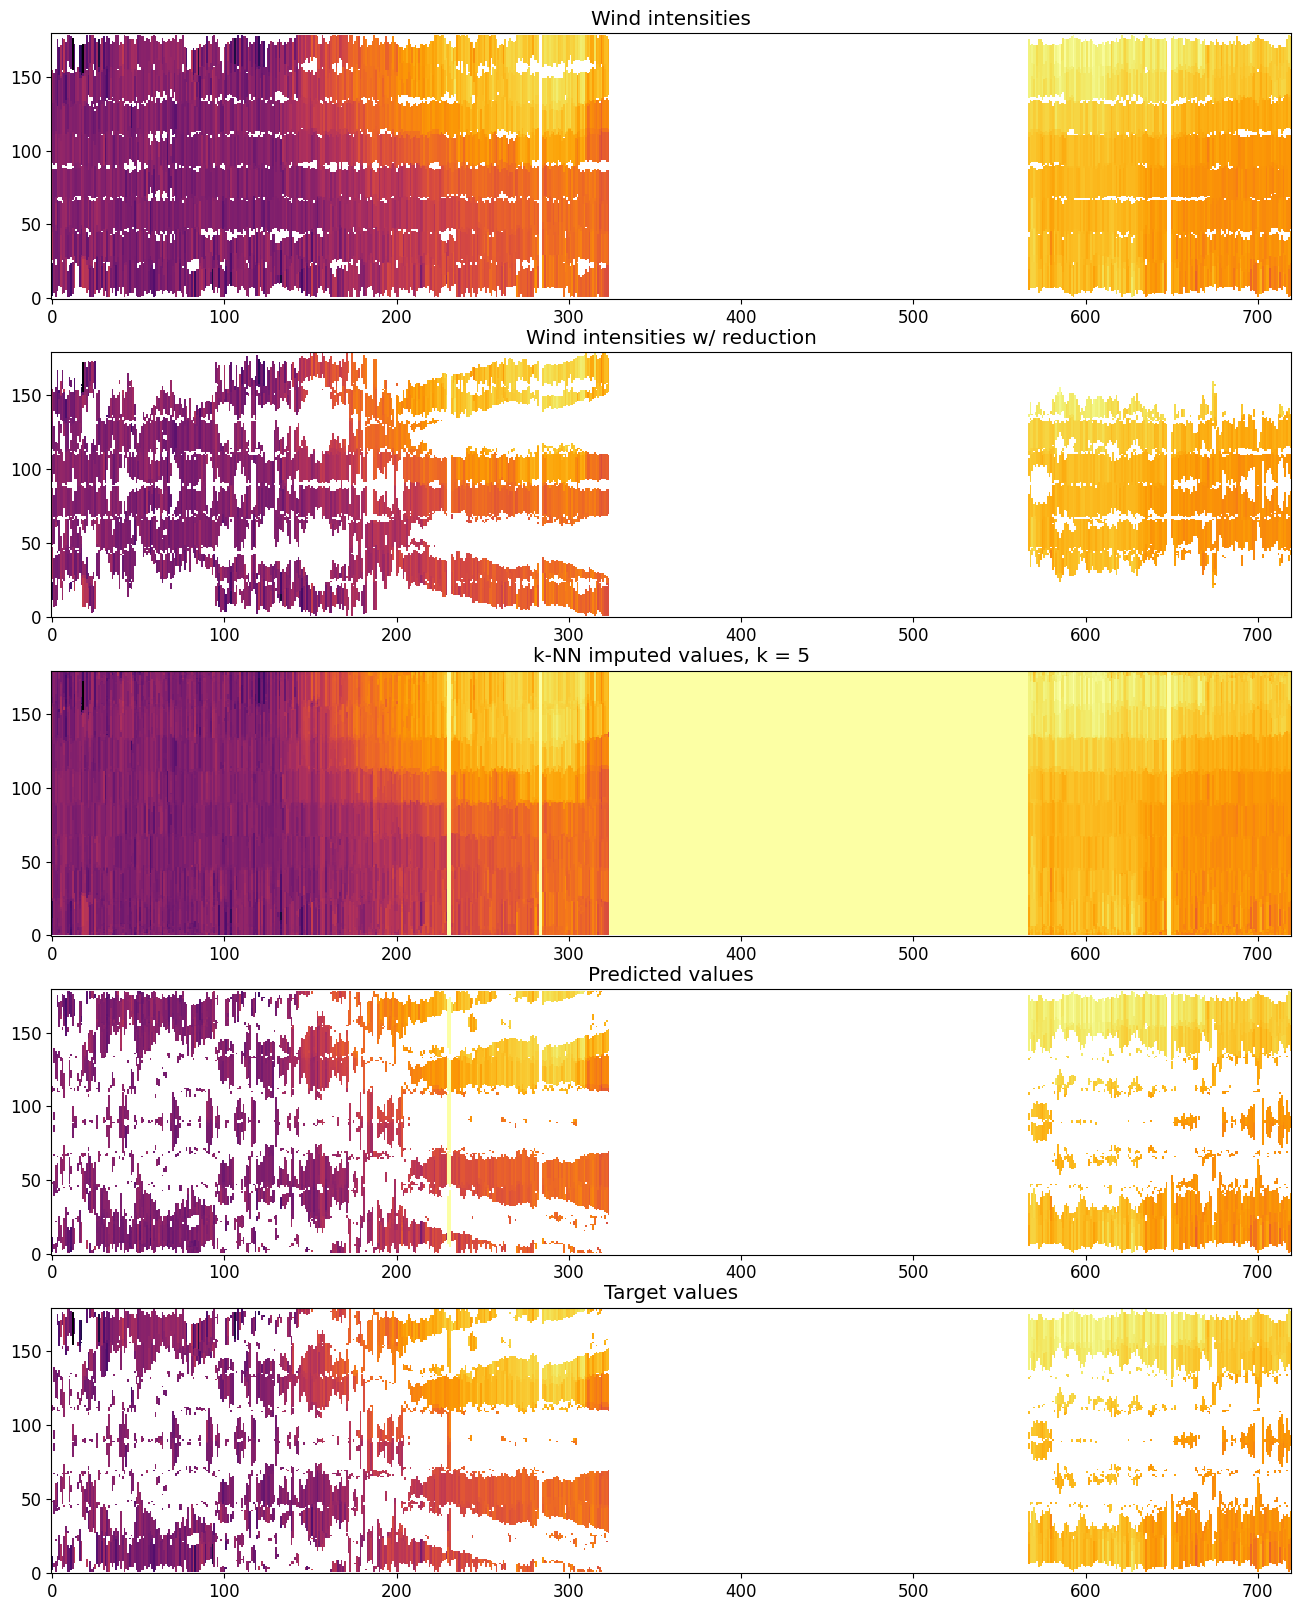

In [ ]:
fig, axs = plt.subplots(nrows=5, figsize=(16,20))
vmin = np.nanmin(true)
vmax = np.nanmax(true)
norm = LogNorm(vmin,vmax)

axs[0].pcolormesh(X, Y, true, norm=norm, cmap="inferno")
axs[0].set_title("Wind intensities")
axs[1].pcolormesh(X, Y, reduced, norm=norm, cmap="inferno")
axs[1].set_title("Wind intensities w/ reduction")
axs[2].pcolormesh(X, Y, pred_full, norm=norm, cmap="inferno")
axs[2].set_title(f"k-NN imputed values, k = {5}")
axs[3].pcolormesh(X, Y, pred, norm=norm, cmap="inferno")
axs[3].set_title("Predicted values")
axs[4].pcolormesh(X, Y, target, norm=norm, cmap="inferno")
axs[4].set_title("Target values")

In [23]:
from numpy.lib.stride_tricks import sliding_window_view
# n_train = 150
# n_test = 50

hist_list = []
reduced_hist_list = []
intensity_list = []

# TODO handle metadata
for file in load_path.iterdir():
    try:
        npz = np.load(file)
        hist = npz["full"]
        reduced_hist = npz["reduced"]
        intensity = npz["intensity_data"]
        hist_list.append(hist)
        reduced_hist_list.append(reduced_hist)
        intensity_list.append(intensity)
    except ValueError:
        print(traceback.format_exc())
        continue

X_train, X_test, y_train, y_test, I_train, I_test = train_test_split(hist_list, reduced_hist_list, intensity_list, random_state=123, shuffle=True)

#model = pickle.load(open('knnimputer_20251207', 'rb'))

# Concatenate contiguous rows to one feature vector (5 * 180 = 900 features)
trains = []
for train in X_train:
    train_stacked = sliding_window_view(train, window_shape=(5,180)).reshape(-1, 5 * train.shape[1])   # ChatGPT solution
    trains.append(train_stacked)

X_train_stacked = np.vstack(trains)

#model = pickle.load(open('knnimputer_20251207', 'rb'))

In [24]:
X_train_stacked.shape

(127448, 900)

In [25]:
model_path = Path("./data/models")
model_path.mkdir(exist_ok=True)

neighbors = 5

model = KNNImputer(n_neighbors=neighbors, weights="distance", keep_empty_features=True)
model.fit(X_train_stacked)
dump_file = open(model_path / f'knnimputer_20250111', 'wb')
pickle.dump(model, dump_file)
dump_file.close()

In [26]:
def _plot_hist(x):
    print(f"Plotting histogram of shape: {x.shape}")
    fig, axs = plt.subplots(nrows=1, figsize=(16,4))

    X, Y = np.meshgrid(np.arange(0, x.shape[0]), np.arange(0, x.shape[1]), indexing="ij")
    norm = LogNorm(np.nanmin(x), np.nanmax(x))
    axs.pcolormesh(X, Y, x, norm=norm, cmap="inferno")
    axs.set_title("Debug")
    plt.show()

Training data: every instance (angle vector / timestamp) is appended with the next 4 -> 900 features. This is then vstacked and fed into the model as array of shape (# of total timestamps, 900).
Test histograms are reshaped to contain 900 features. R2 score is calculated for each 5 x 180 block.

TODO: make reshaping stuff cleaner.

In [ ]:
for j, test in enumerate(y_test):
    true = X_test[j]
    reduced = np.where(np.isfinite(test), true, np.nan)

    reduced_reshaped = reduced.reshape((144,900))
    pred_full_reshaped = model.transform(reduced_reshaped)
    pred_full = pred_full_reshaped.reshape((720,180))

    X, Y = np.meshgrid(np.arange(0, true.shape[0]), np.arange(0, true.shape[1]), indexing="ij")
    pred = np.where((np.isnan(reduced) 
                    & np.isfinite(true) 
                    & np.meshgrid(np.isfinite(reduced).any(axis=1), np.arange(0, reduced.shape[1]), indexing="ij")[0]), 
                    pred_full, np.nan)
    target = np.where(np.isfinite(pred), true, np.nan)

    pred_reshaped = pred.reshape((144,900))
    target_reshaped = target.reshape((144,900))

    scores = []
    for i, _ in enumerate(pred_reshaped):
        if np.any(np.isfinite(target_reshaped[i])) and np.any(np.isfinite(pred_reshaped[i])):
            scores.append(r2_score(target_reshaped[i][np.isfinite(target_reshaped[i])], pred_reshaped[i][np.isfinite(pred_reshaped[i])]))
        else:
            scores.append(np.nan)

    fig, axs = plt.subplots(nrows=7, figsize=(16,28), sharex=True)

    norm = LogNorm(np.nanmin(true), np.nanmax(true))
    for i in range(8):
        axs[0].plot(I_test[j][:,i], label=wind.sectors[i])
    axs[0].set_title("Intensities")
    axs[0].set_yscale("log")
    axs[0].legend(loc="upper right")
    axs[1].pcolormesh(X, Y, true, norm=norm, cmap="inferno")
    axs[1].set_title("Wind PAD")
    axs[2].pcolormesh(X, Y, reduced, norm=norm, cmap="inferno")
    axs[2].set_title("Wind PAD w/ reduction")
    axs[3].pcolormesh(X, Y, pred_full, norm=norm, cmap="inferno")
    axs[3].set_title(f"k-NN imputed values, k = {neighbors}")
    axs[4].pcolormesh(X, Y, pred, norm=norm, cmap="inferno")
    axs[4].set_title("Predicted values")
    axs[5].pcolormesh(X, Y, target, norm=norm, cmap="inferno")
    axs[5].set_title("Target values")
    axs[6].plot(np.arange(0,720,5), scores)
    axs[6].set_title("R2 score per 5 x 180 block")
    
    plt.savefig(plot_path / f"results_{j}.png")
    plt.close()